# Decision Trees in Python

Next, we will see how to build decision trees in Python. We will use the Titanic data set. 


## Titanic Data

The Titanic was an infamous ocean liner that sank on its maiden voyage on April 15, 1912 after hitting an iceberg. 

https://en.wikipedia.org/wiki/Titanic

Out of about 2200 passengers and crew on board, an estimated 1500 died. The data set below contains information on 1309 out of the approximately 1500 passengers. We are interested in building a model to predict which passengers lived and which died. 

Much of the analysis here is based on the analysis at this link:

https://www.kaggle.com/code/dmilla/introduction-to-decision-trees-titanic-dataset


Read in the data: 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
titanic=pd.read_csv("../../../../Data/Titanic/Titanic.csv")

In [5]:
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


The variable **survived** is the response. It is 1 if the passenger survived and zero if not. 

**pclass** is the class of the ticket and take values 1, 2, or 3. 

There are two variables related to the membership in families: **sibsp** is the number of siblings or spouses on board. **parch** is the number of parents of children on board. 

**Fare** is the amount paid for the passengers ticket. 

**Cabin** gives the cabin number

**embarked** gives the port of Embarkation:C = Cherbourg, Q = Queenstown, S = Southampton

**body** is body identification number. 

**boat** is a number for the lifeboat they were on, if applicable. 

Other variables are self-explanatory. 

We will create a new variable `FamilySize` that is the sum of `sibsp` and `parch`:

In [6]:
titanic['FamilySize']=titanic['sibsp']+titanic['parch']

We will also create a new variable `IsAlone` based on family size. It is 0 if the person had no family members on board and 1 if they did:

In [7]:
titanic['IsAlone']=np.where(titanic['FamilySize']>0,0,1)

Next, we will turn `fare` into a cateogorical varable:

In [8]:
titanic.loc[ titanic['fare'] <= 7.91, 'fare']= 0
titanic.loc[(titanic['fare'] > 7.91) & (titanic['fare'] <= 14.454), 'fare'] = 1
titanic.loc[(titanic['fare'] > 14.454) & (titanic['fare'] <= 31), 'fare']   = 2
titanic.loc[ titanic['fare'] > 31, 'fare']=3

We will use the decsion tree function in the `sklearn` module. This function only allows numeric variables. Thus, we will convert categorical variables to numeric:

In [9]:
titanic['sex'] = titanic['sex'].map( {'female': 0, 'male': 1} ).astype(int)
titanic['embarked'] = titanic['embarked'].fillna('S')
titanic['embarked'] = titanic['embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int)

Here is the updated data set:

In [10]:
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,FamilySize,IsAlone
0,1,1,"Allen, Miss. Elisabeth Walton",0,29.0000,0,0,24160,3.0,B5,0,2,NaN,"St Louis, MO",0,1
1,1,1,"Allison, Master. Hudson Trevor",1,0.9167,1,2,113781,3.0,C22 C26,0,11,NaN,"Montreal, PQ / Chesterville, ON",3,0
2,1,0,"Allison, Miss. Helen Loraine",0,2.0000,1,2,113781,3.0,C22 C26,0,NaN,NaN,"Montreal, PQ / Chesterville, ON",3,0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",1,30.0000,1,2,113781,3.0,C22 C26,0,NaN,135.0,"Montreal, PQ / Chesterville, ON",3,0
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",0,25.0000,1,2,113781,3.0,C22 C26,0,NaN,NaN,"Montreal, PQ / Chesterville, ON",3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",0,14.5000,1,0,2665,2.0,NaN,1,NaN,328.0,NaN,1,0
1305,3,0,"Zabour, Miss. Thamine",0,NaN,1,0,2665,2.0,NaN,1,NaN,NaN,NaN,1,0
1306,3,0,"Zakarian, Mr. Mapriededer",1,26.5000,0,0,2656,0.0,NaN,1,NaN,304.0,NaN,0,1
1307,3,0,"Zakarian, Mr. Ortin",1,27.0000,0,0,2670,0.0,NaN,1,NaN,NaN,NaN,0,1


We will take a final data set consisting of the variable below:

In [15]:
titanicFinal=titanic[['survived','pclass','sex','age','fare','embarked','FamilySize']]
titanicFinal
titanicFinal.to_csv("TitanicFinal.csv",index=False)

### Training and Test Data

We will now split the data into test and training data. We will use the `sklearn` module for most of work with decision trees. 

In [12]:
import sklearn as skl
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import accuracy_score, classification_report

We specify the predictors and response:

In [11]:
X = titanicFinal.drop(columns=["survived"])
y = titanicFinal["survived"]

The function `train_test_split` randomly splits the data. The parameter `test_size` specifies the percentage of the data that is test data. `random_state` is similar to `set.seed` in R. 

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=12)

### Making the tree

Make the decision tree. The paramter `max_depth` determines the maximim number of splits:

In [39]:
clf=tree.DecisionTreeClassifier(max_depth=5, random_state=12)

In [40]:
clf=clf.fit(X_train,y_train)

### Plotting the tree

Plot the fitted tree. 

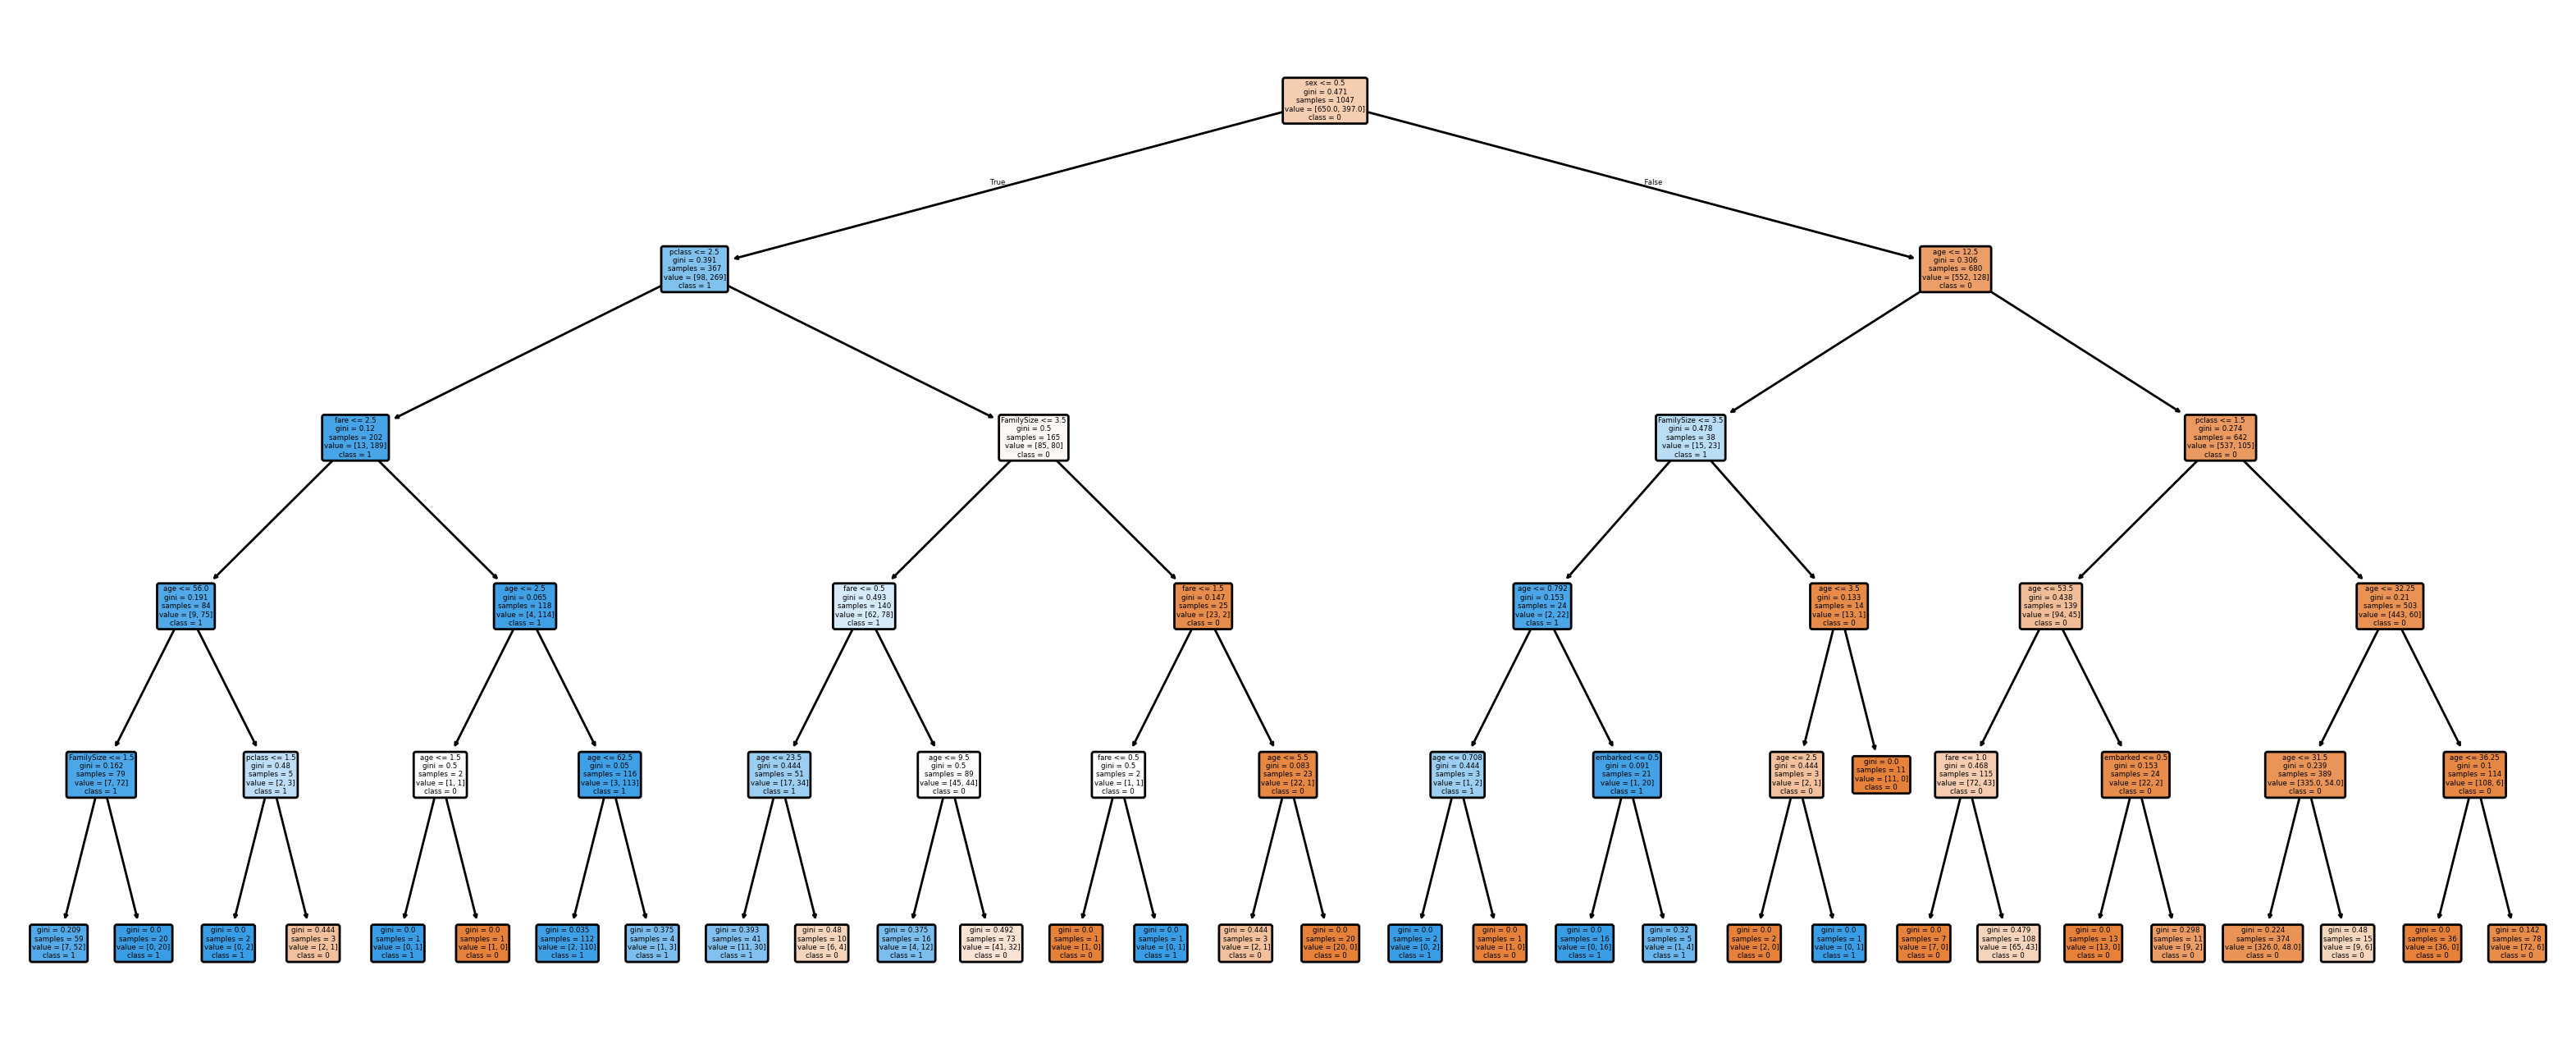

In [41]:
plt.figure(figsize=(20, 8),dpi=200)
tree.plot_tree(
    clf,
    feature_names=X.columns.tolist(),
    class_names=clf.classes_.astype(str).tolist(),
    filled=True,
    rounded=True
)
plt.show()

In the tree, each node shows
- The condition for the split
- The Gini index for the split
- The number of samples in the node
- The counts for the two classes. E.g. [650,397] in the first node means 650 samples in the node have `survived=0` and 397 have `survived=1`. 
- The predicted class for the node (the most common class is the predicted class). 

We see that the first split happens on sex: 269 women the training sample survived and 98 died. In contrast, only 128 men survived and 552 died. This is likely because women were given first priority for life boats. 

Within women, the next split was on passenger c. Passengers were more likely to die if they were third class than second or first.  

For males, the second split was on age. Boys under 12.5 were more likely to survive than older males. 

For both third class females and younger boys, the next split was on family size. In both cases, traveling with larger families made people much more likely to die.     

There are more splits as we go down the tree.

Note: I get different results depending on whether I run this on my laptop or my desktop. This is likely because I am running different versions of the python packages on the two computers and there are small differences in the algorithms. Thus, you may get different results when you run it. This is indicative of the instability of decision trees (more below).   


### Accuracy of Predictions

Next, check accuracy of predictions on test data: 

In [42]:
y_pred=clf.predict(X_test)

The function `accuracy_score` shows the percent of correct predictions:

In [43]:
print(accuracy_score(y_test, y_pred))

0.7748091603053435


The function `classification_report` gives fuller report of results:

In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.92      0.83       159
           1       0.81      0.55      0.66       103

    accuracy                           0.77       262
   macro avg       0.79      0.74      0.75       262
weighted avg       0.78      0.77      0.76       262



The precision for a class $k$ is $\frac{\text{true positives for k}}{\text{all positive results for k}}=\frac{\text{true positives for k}}{\text{true positives for k + false positives for k}}$. We have previously called this **positive predictive ability**. 

The recall is $\frac{\text{true positives for k}}{\text{all effects that are actually k}}=\frac{\text{true positives for k}}{\text{true positives for k + false negatives for k}}$. This is also known as the **sensitivity**. 

We see that the precision for survival is 81% - meaning that 81% of postives results are true positives. In this case, a positive result means survival. 

We see that the recall for survival is 55% - meaning that only 55% of people who survived were correctly predicted as surviving. The recall was 92% for not surviving. 

### Cross validation for tree depth

#### Exercise: Rerun and plot the tree with a different test and training set. How similar is the tree? 


When we fit the tree again with a different random split of test and training data, we see that the splits at the top levels are similar. The most important determinant of survival is male versus female. Within females, the next split is on passenger class, etc. However, as we move down the tree, the splits are different. This suggests that these splits may be overfitting and not true effects in the data. 

We can use cross validation to find the best tree depth. We do a loop over the `max_depth` parameter. The function `cross_val_score` does cross validation on the fitted tree `clf`. The option `scoring` specifies how performance is quantified. 

In [53]:
from sklearn.model_selection import cross_val_score

# --- Test a range of depths ---
depths = range(1, 10)
mean_scores = []
std_scores = []

for depth in depths:
    clf = tree.DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy")
    mean_scores.append(scores.mean())
    std_scores.append(scores.std())



Plot the results:

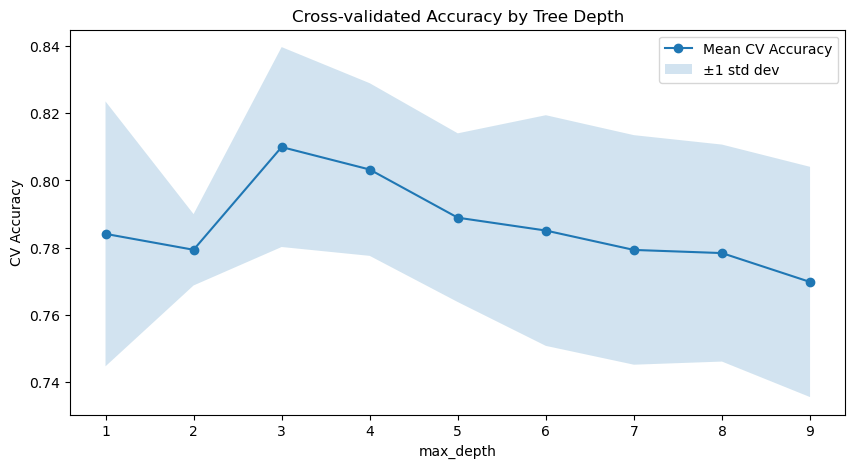

Best depth: 3


In [54]:
# --- Plot results ---
plt.figure(figsize=(10, 5))
plt.plot(depths, mean_scores, marker="o", label="Mean CV Accuracy")
plt.fill_between(depths,
    np.array(mean_scores) - np.array(std_scores),
    np.array(mean_scores) + np.array(std_scores),
    alpha=0.2, label="±1 std dev")
plt.xlabel("max_depth")
plt.ylabel("CV Accuracy")
plt.title("Cross-validated Accuracy by Tree Depth")
plt.legend()
plt.show()

# --- Best depth ---
best_depth = depths[np.argmax(mean_scores)]
print(f"Best depth: {best_depth}")

Plot the tree with depth 3: 

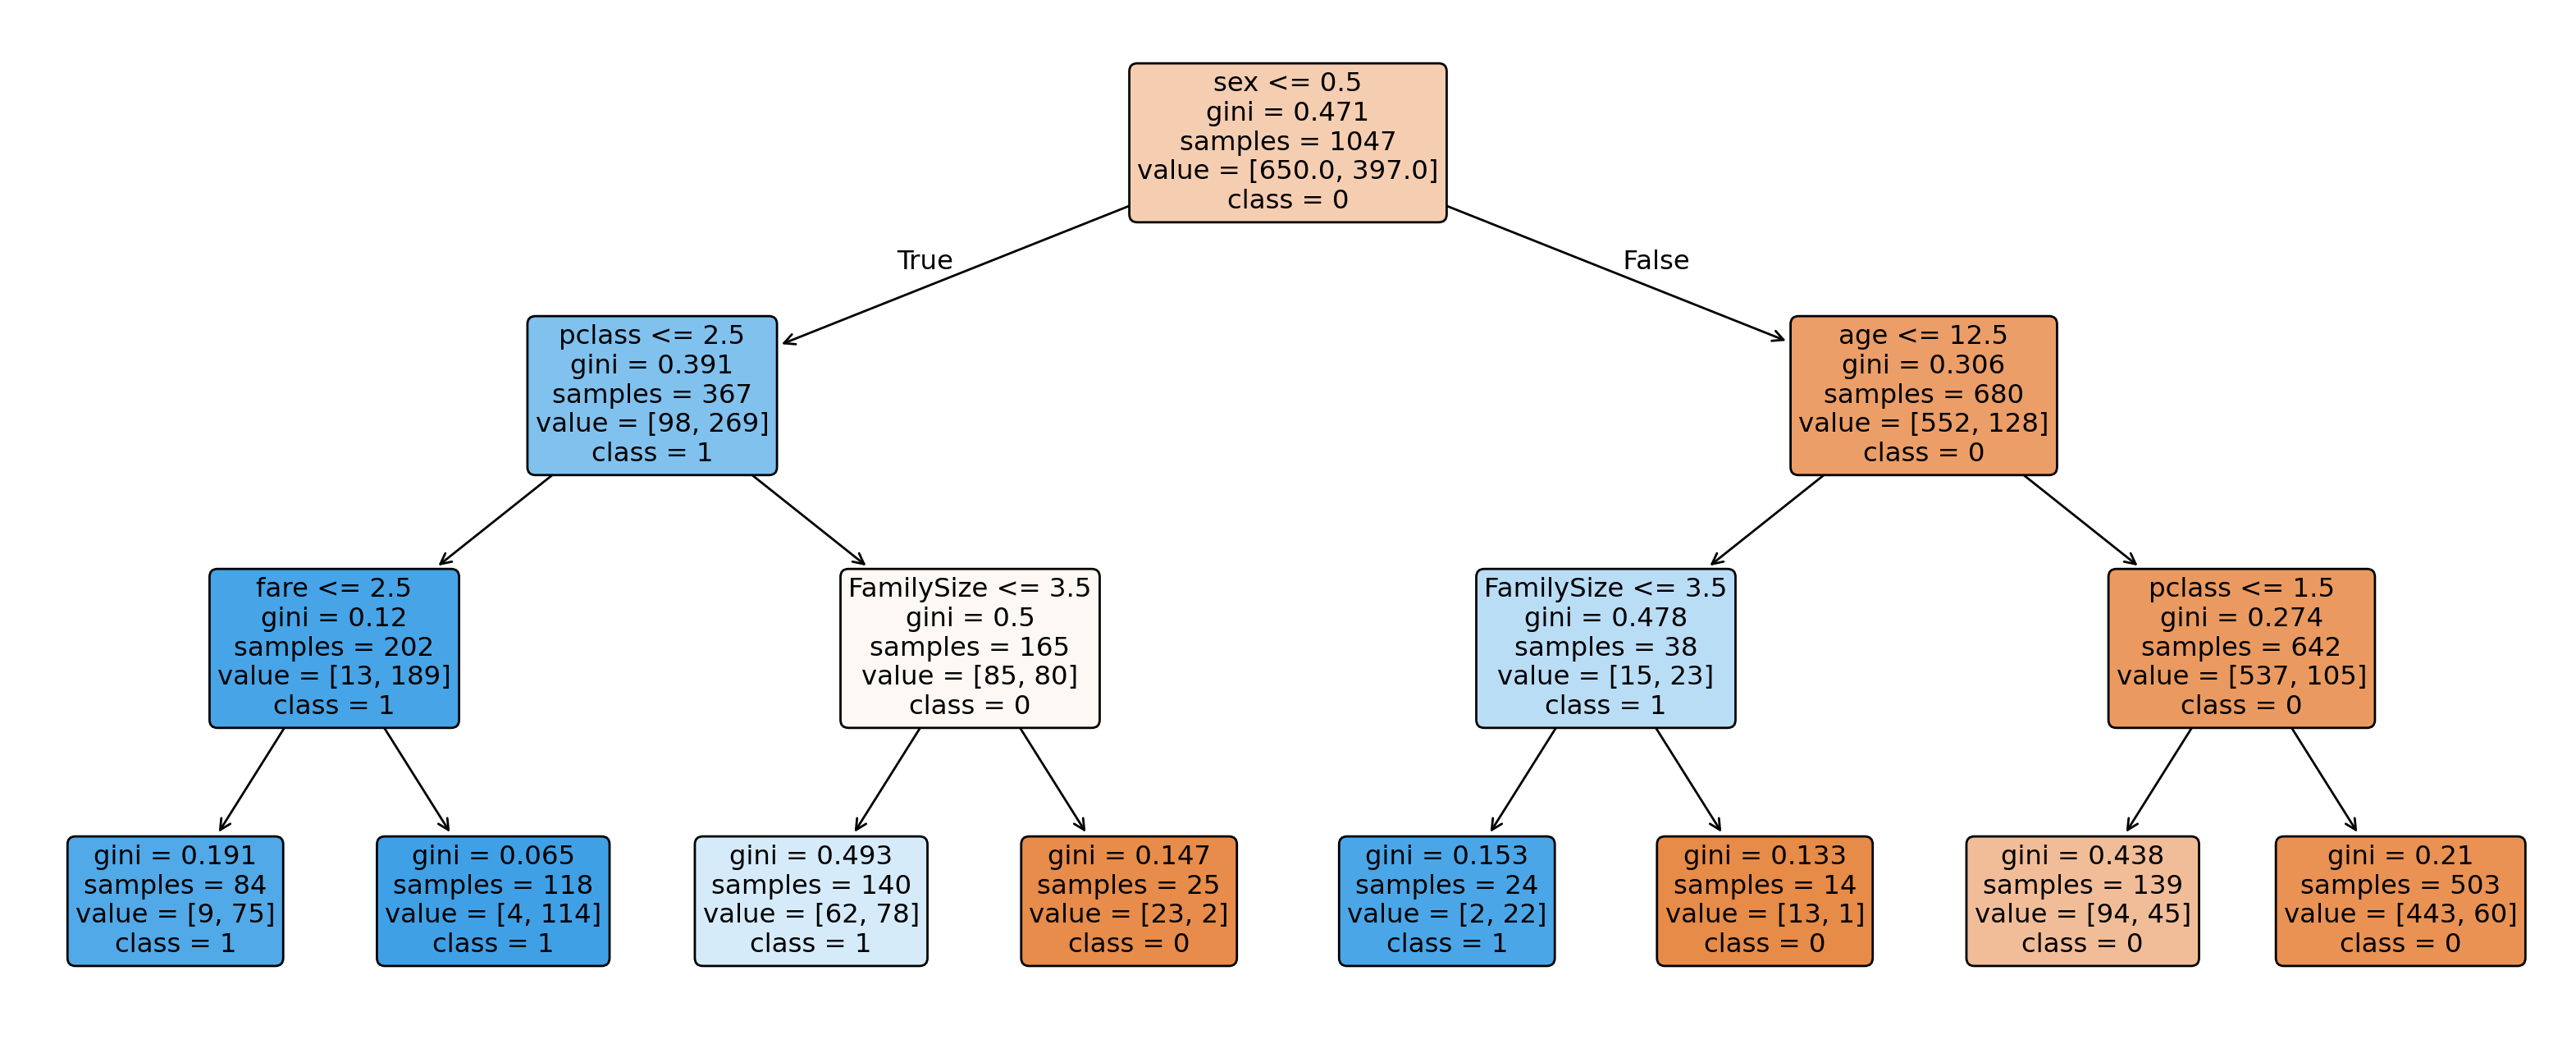

In [55]:
clf3=tree.DecisionTreeClassifier(max_depth=3, random_state=12)
clf3=clf3.fit(X_train,y_train)
plt.figure(figsize=(20, 8),dpi=200)
tree.plot_tree(
    clf3,
    feature_names=X.columns.tolist(),
    class_names=clf3.classes_.astype(str).tolist(),
    filled=True,
    rounded=True
)
plt.show()

Another option to control tree complexity is the minimum samples per leaf. This is specified by argument `min_samples_leaf`. It is set to 30 in the example below. This has the effect that no split will be executed that would result in a group size of less than 30. 

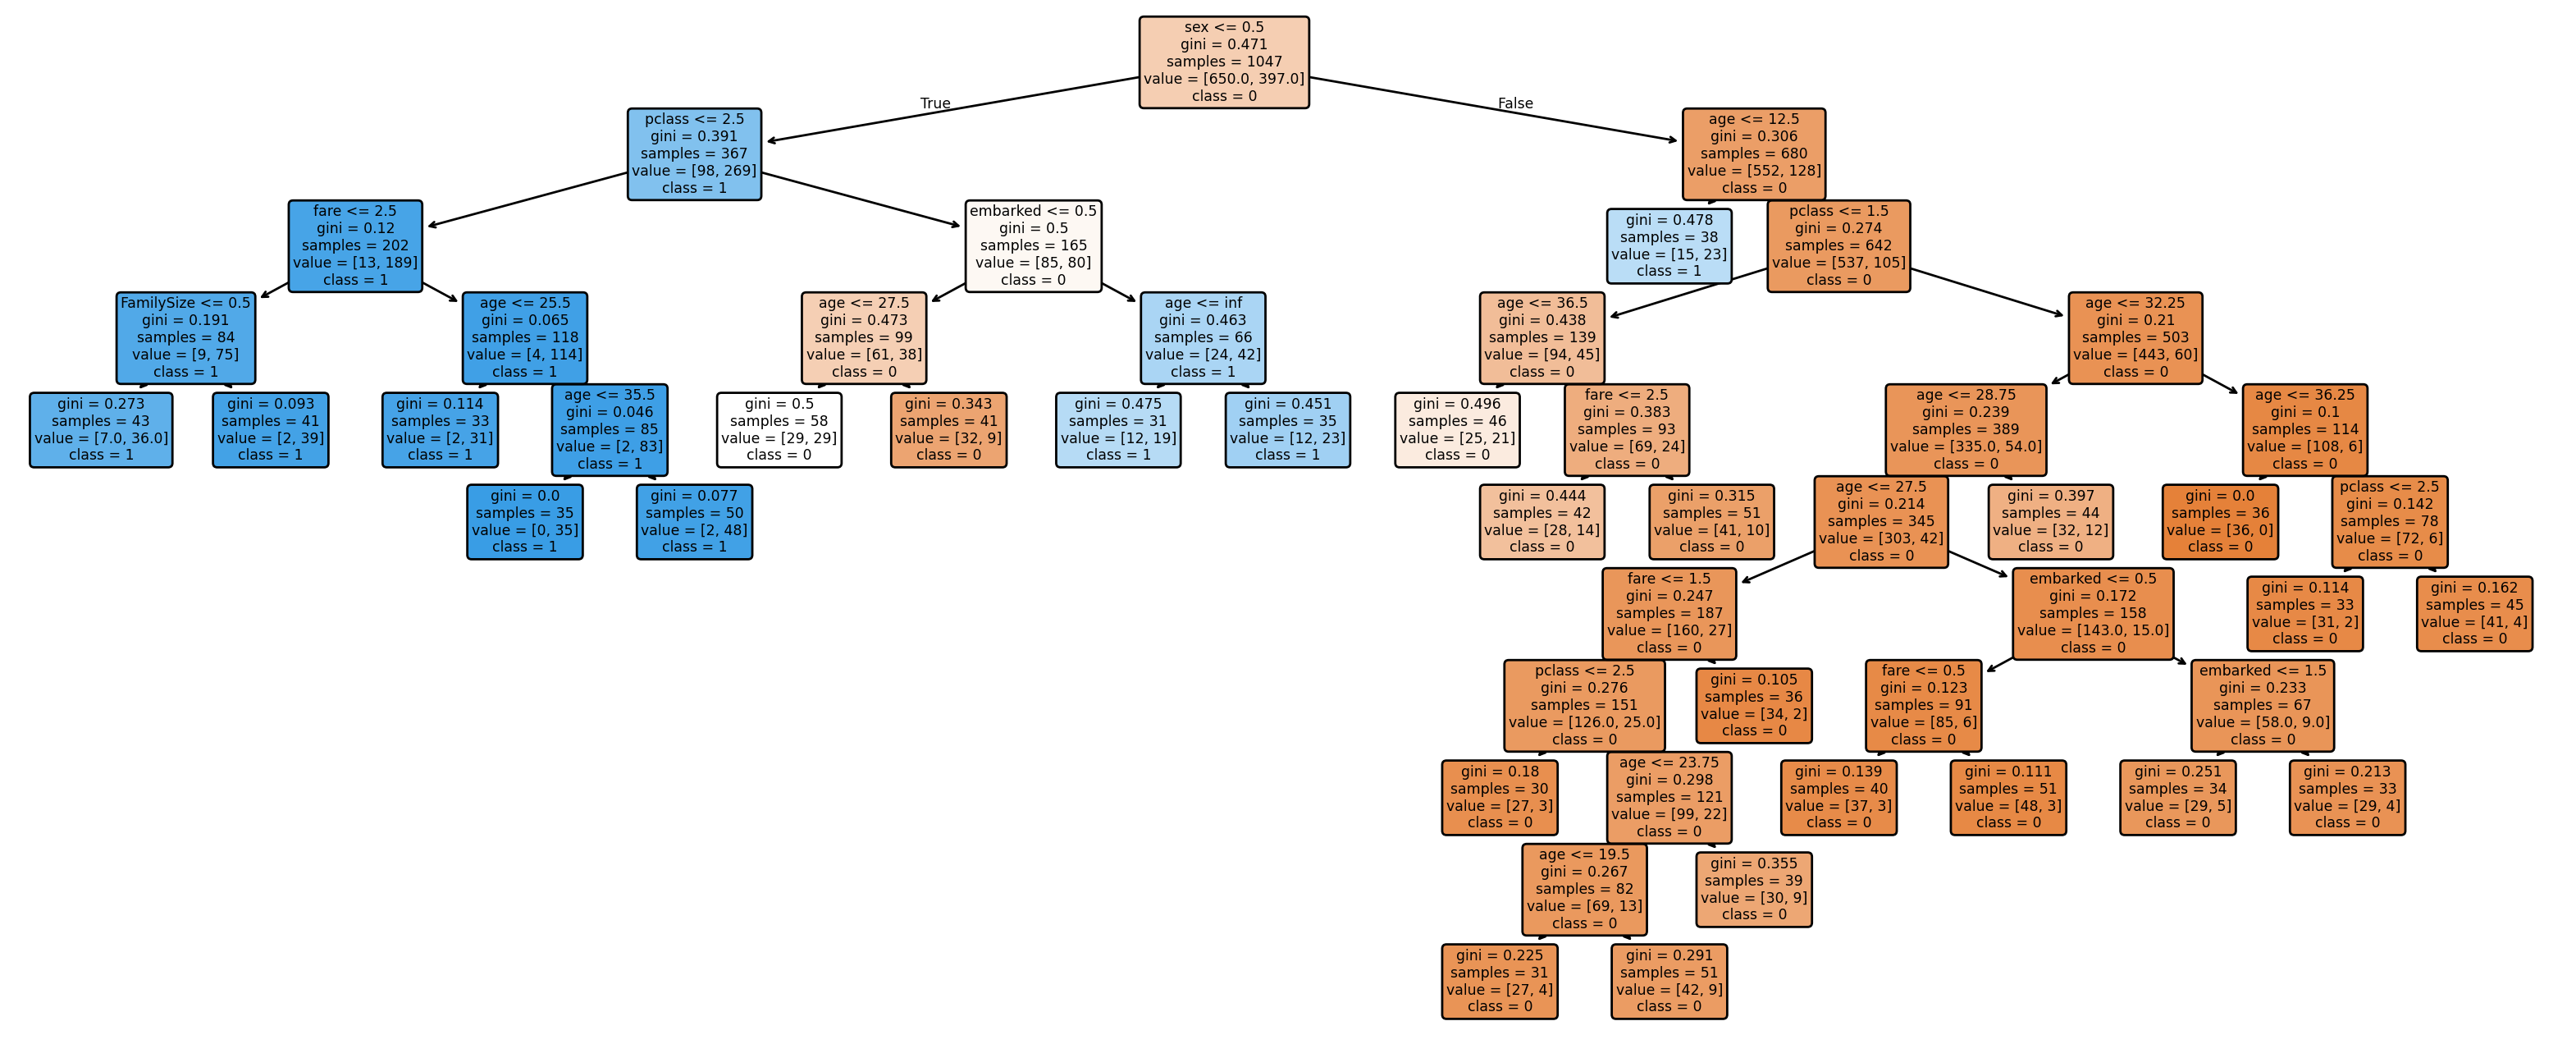

In [56]:
clf4=tree.DecisionTreeClassifier(min_samples_leaf=30, random_state=12)
clf4=clf4.fit(X_train,y_train)
plt.figure(figsize=(20, 8),dpi=200)
tree.plot_tree(
    clf4,
    feature_names=X.columns.tolist(),
    class_names=clf4.classes_.astype(str).tolist(),
    filled=True,
    rounded=True
)
plt.show()

### Pruning

The maximum depth and minimum samples approaches limit the growth of the tree from the beginning. **Pruning** is another alternative for controlling tree complexity. It takes a fitted tree and removes nodes. Pruning is based on the **cost-complexity measure** $R_\alpha(T)$ of a tree $T$:

$$R_\alpha(T)=R(T)+\alpha|\tilde{T}|$$


$\tilde{T}$ is the number of terminal nodes of tree $T$ and $R(T)$ is some measure of misclassification rate, such as the total misclassification rate or the Ginni index. The `sklearn` module uses the Ginni index, also known as the **node impurity**.  The goal is to minimize $R(T)$. Increasing the complexity of the tree will decrease $R(T)$ but increases $|\tilde{T}|$. Thus the second term controls overfitting. The parameter $\alpha$ controls the balance between over and underfitting. 

The cost-complexity measure of a single node $t$ is $R_{\alpha}(t)=R(t)+\alpha$, where $R(t)$ is the node impurity (or other measure) for the node. The cost-complexity measure for the subtree descending $T_t$ from the node $t$ is denoted by $R_\alpha(T_t)=R(T_t)+|T_t|\alpha$. In general, the node impurity will be higher for node $t$ than summed across the terminal nodes descending from it.

$$R(t)>R(T_t)$$. 

This is because making more complex subtrees will reduce the error rate in the training data. However, depending on the value of $\alpha$, the cost-complexity for the descendend tree may exceed that for the single node because of the complexity penalty. The value of $\alpha$ where these two quanties are equal is known as the **effective $\alpha$**. 

$$\alpha_{eff}=\alpha: R_{\alpha}(t)=R_{\alpha}(T_t) \rightarrow \alpha: R(t)+\alpha=R(T_t)+|T_t|\alpha$$. 

or

$$\alpha_{eff}(t)=\frac{R(t)-R(T_t)}{|T_t|-1}$$

This is the $\alpha$ threshold at which this branch of the tree will be pruned. If $\alpha$ is any higher (remember that $\alpha$ penalizes for tree complexity), then the cost-complexity for pruning the branch is higher than that for keeping the branch. A non-terminal node with the smallest value of is the weakest link and will be pruned. 
    
Cost-complexity pruning can be done with the `DecisionTreeClassifier` function by specifying the `ccp_alpha` parameter. It then prunes all branches with $alpha_{eff}$<`cc_alpha`. 


The `sklearn` function `cost_complexity_pruning_path` can be used to find the $\alpha_{eff}$ values and the associated values of the Gini impurity. I used these to make a plot of the impurity measure versus the effective alpha:

In [57]:
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

Next, we plot the impurity measure versus the effective alpha.

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

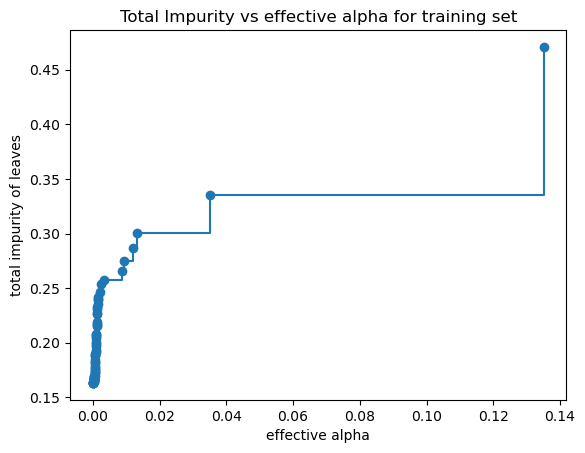

In [73]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas, impurities, marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

As `effective alpha` increases, more branches are pruned and the impurity increases (meaning less accurate prediction in the training data). Next, we train a decision tree for each level of effective alpha `ccp_alpha`. 

In [74]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = tree.DecisionTreeClassifier(random_state=12, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

Next, we plot the number of nodes and the tree depth versus `effective alpha`:

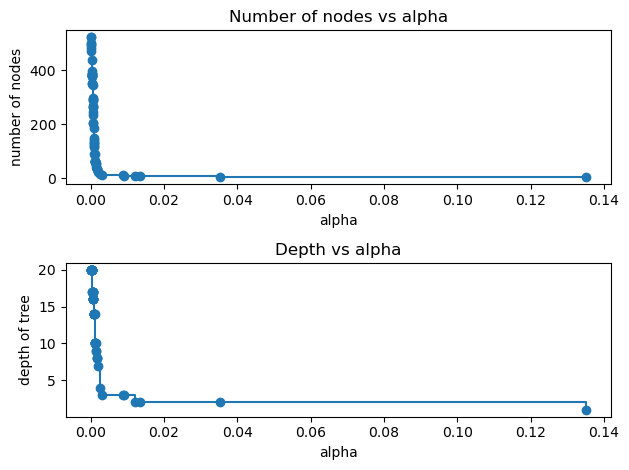

In [75]:
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

These plots demonstrate how the complexity of the tree reduces as we increase `effective alpha`. This will lead to more accurate classification in the training data, but also overfitting. We can use training/test data or cross validation to decide the optimal `effective alpha`. Below I use test data. `clf.score` returns the mean accuracy of prediction (percent correct predictions).   

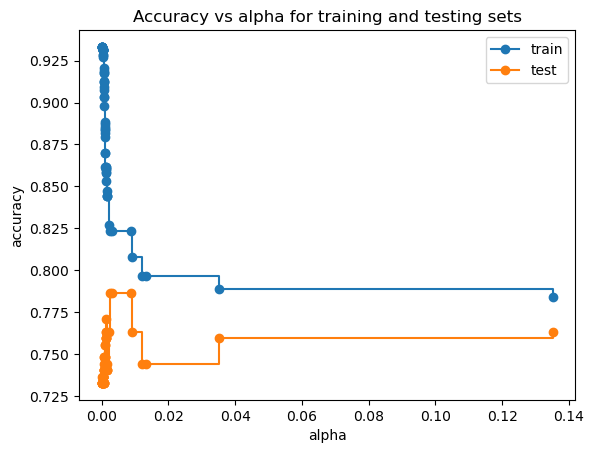

In [77]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

We see that accuracy is at its maximum for the testing data at around 0.01. Below I zoom in more: 

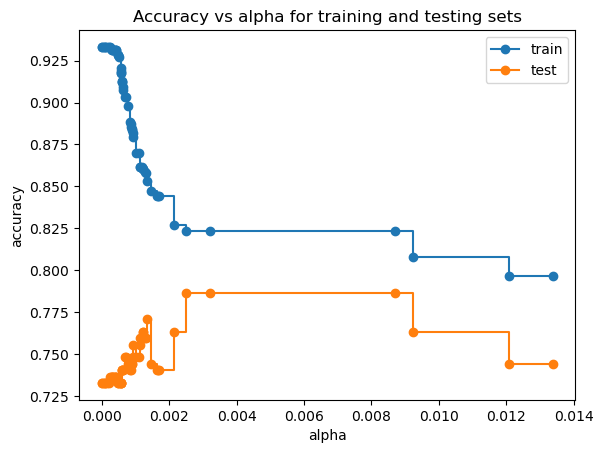

In [82]:
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas[:-2], train_scores[:-2], marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas[:-2], test_scores[:-2], marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

Test accuracy is maximized in the range of approximately 0.003 to 0.008. I will take 0.006 and plot the tree:

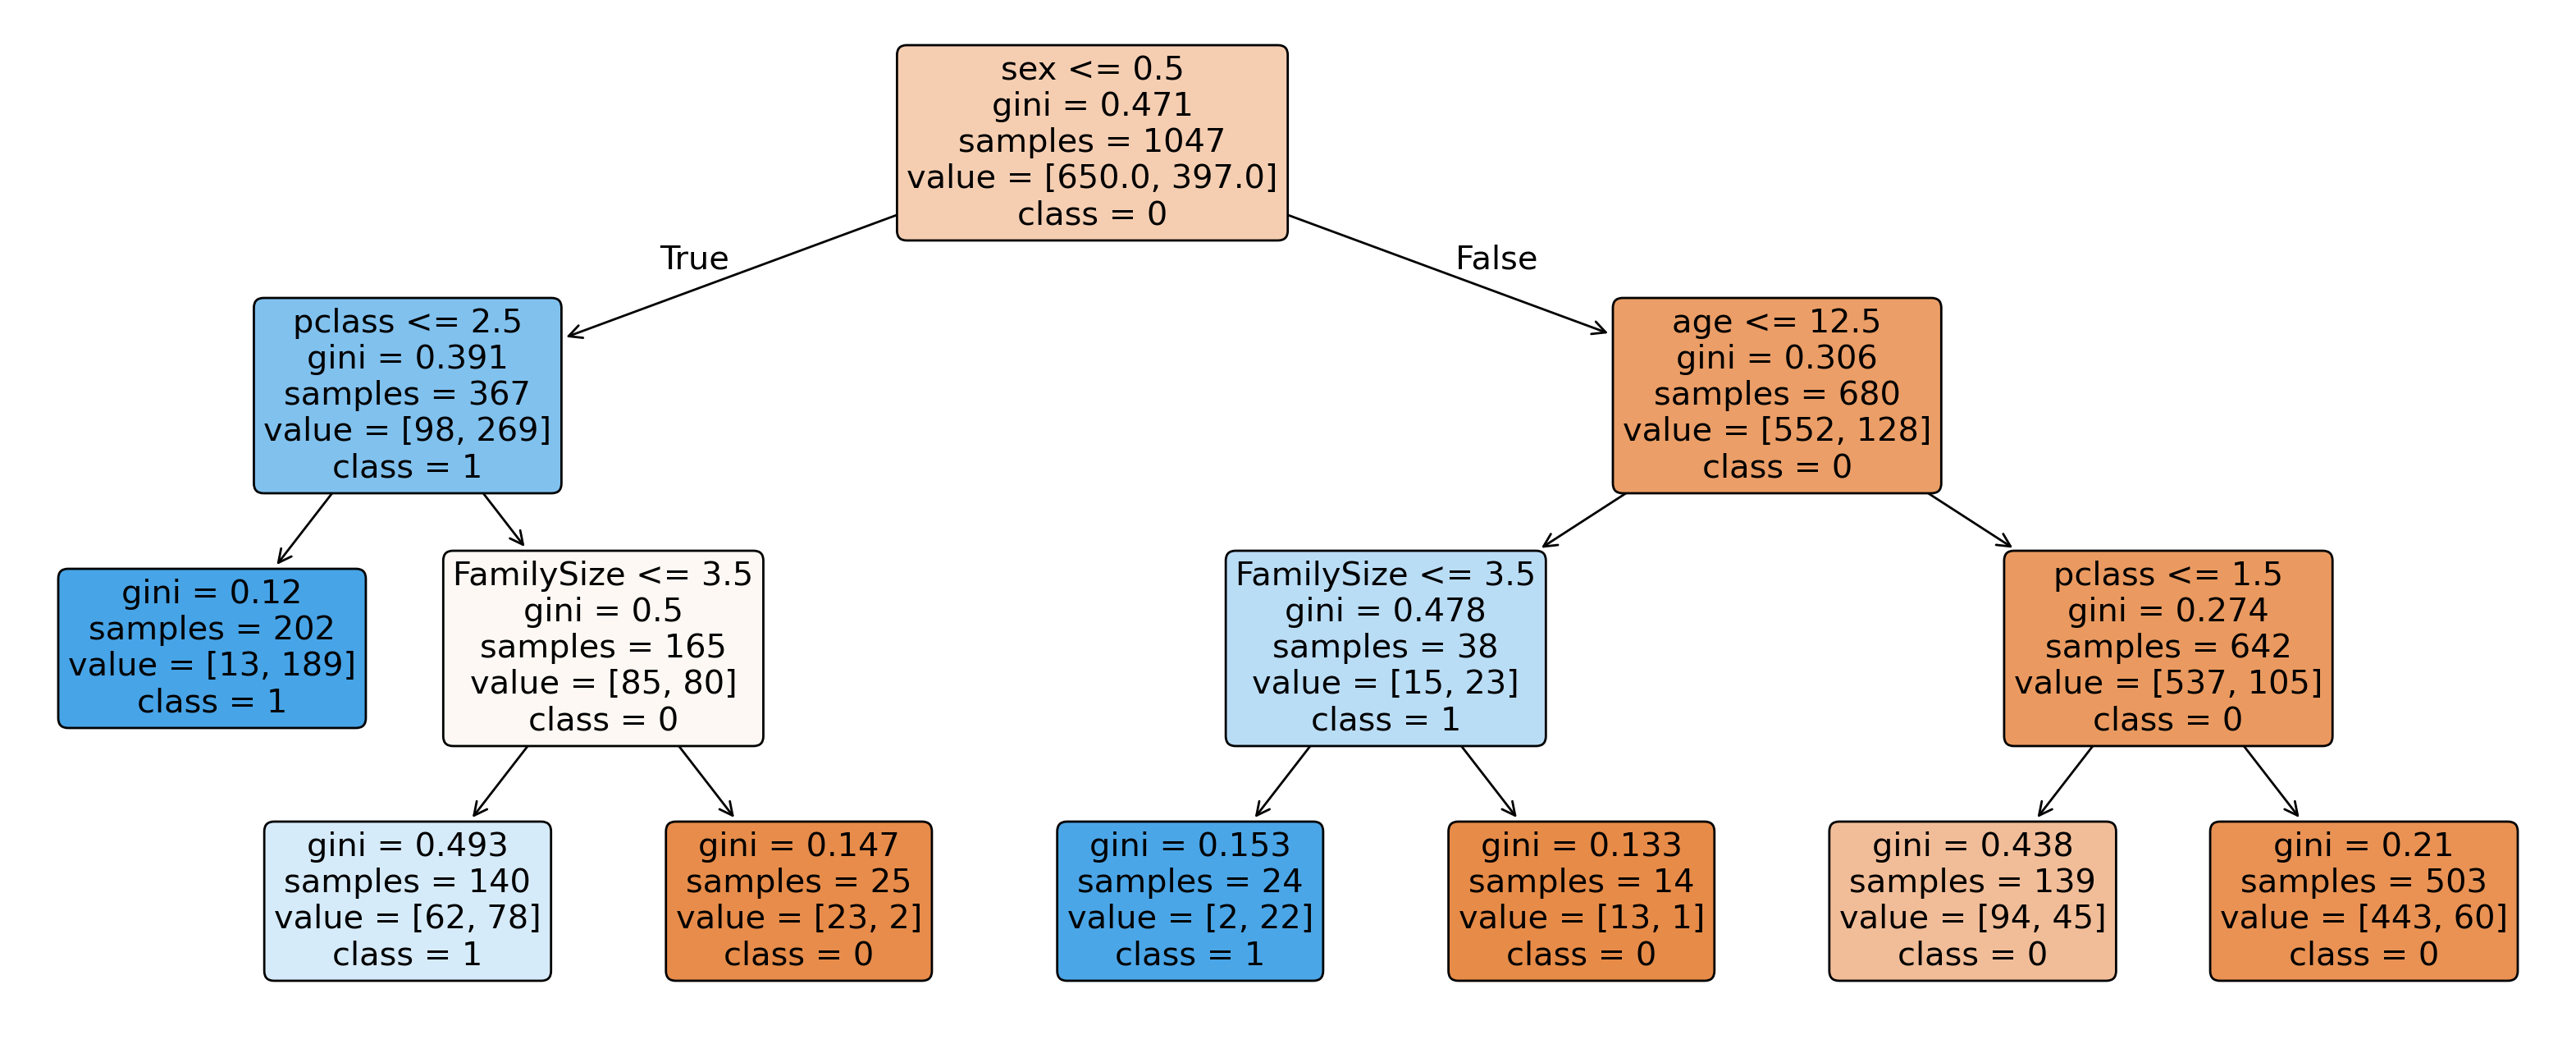

In [83]:
clffinal=tree.DecisionTreeClassifier(ccp_alpha=0.006, random_state=12)
clffinal=clffinal.fit(X_train,y_train)
plt.figure(figsize=(20, 8),dpi=200)
tree.plot_tree(
    clffinal,
    feature_names=X.columns.tolist(),
    class_names=clffinal.classes_.astype(str).tolist(),
    filled=True,
    rounded=True
)
plt.show()

This is similar to the tree that we obtained using cross-validation with tree depth. 